# 📈 ARIMA Model — Monthly Expense Forecasting

**Goal:** Fit an ARIMA model to forecast monthly expenses.

**Pipeline:**
1. Load preprocessed train/test data
2. Stationarity check (ADF test)
3. ACF / PACF analysis → determine p, d, q
4. Fit ARIMA model
5. Forecast & evaluate (MAE, RMSE, MAPE)
6. Save residuals for hybrid model

## ✅ Step 1: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

print('✅ All imports successful')

✅ All imports successful


## ✅ Step 2: Load Preprocessed Data

In [2]:
# Load train and test sets from preprocessing pipeline
train_df = pd.read_csv('data/processed/train_monthly.csv', parse_dates=['date'], index_col='date')
test_df  = pd.read_csv('data/processed/test_monthly.csv',  parse_dates=['date'], index_col='date')

# Set explicit monthly frequency to avoid statsmodels warning
train_df.index = pd.DatetimeIndex(train_df.index).to_period('M').to_timestamp('M')
test_df.index  = pd.DatetimeIndex(test_df.index).to_period('M').to_timestamp('M')

train = train_df['amount']
test  = test_df['amount']

print(f'📅 Train: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} months)')
print(f'📅 Test : {test.index[0].date()} → {test.index[-1].date()}   ({len(test)} months)')
print(f'\n📊 Train stats:\n{train.describe().round(2)}')

📅 Train: 2020-01-31 → 2024-06-30  (54 months)
📅 Test : 2024-07-31 → 2024-12-31   (6 months)

📊 Train stats:
count      54.00
mean     1858.87
std       821.99
min       386.00
25%      1167.00
50%      1827.00
75%      2310.78
max      3651.00
Name: amount, dtype: float64


## ✅ Step 3: Visualize the Time Series

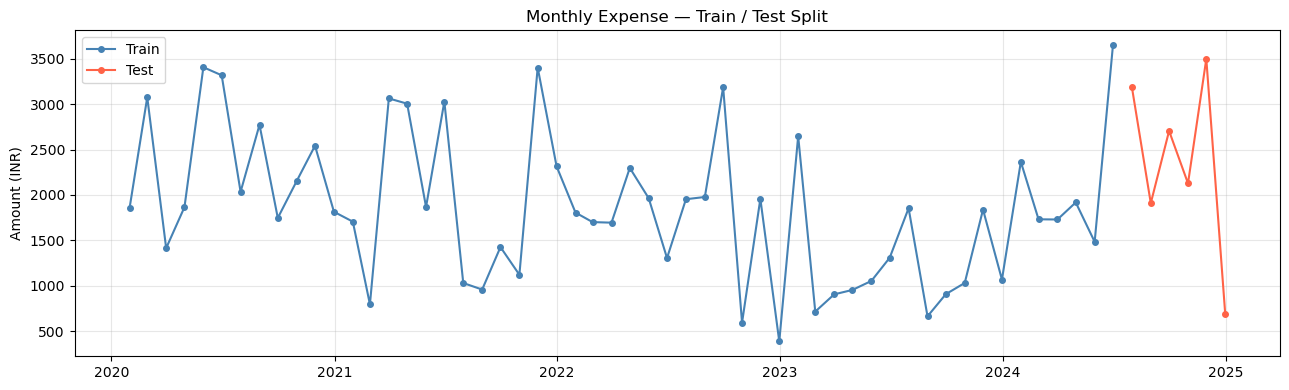

In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train.index, train, label='Train', color='steelblue', marker='o', markersize=4)
ax.plot(test.index,  test,  label='Test',  color='tomato',    marker='o', markersize=4)
ax.set_title('Monthly Expense — Train / Test Split')
ax.set_ylabel('Amount (INR)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ✅ Step 4: Stationarity Check — ADF Test

> **ADF test**: H₀ = series has a unit root (non-stationary).  
> If **p-value < 0.05** → reject H₀ → series is **stationary** → `d = 0`.  
> If **p-value ≥ 0.05** → series is **non-stationary** → difference once (`d = 1`) and retest.

In [4]:
def run_adf(series, label='Series'):
    result = adfuller(series.dropna())
    print(f'── ADF Test: {label} ──')
    print(f'  Test Statistic : {result[0]:.4f}')
    print(f'  p-value        : {result[1]:.4f}')
    print(f'  Critical Values: { {k: f"{v:.3f}" for k, v in result[4].items()} }')
    stationary = result[1] < 0.05
    print(f'  → Series is {"STATIONARY ✅" if stationary else "NON-STATIONARY ❌"}')
    return stationary

# Test original series
is_stationary = run_adf(train, label='Original Train')

# If non-stationary, difference once and retest
if not is_stationary:
    print()
    train_diff = train.diff().dropna()
    run_adf(train_diff, label='1st Difference')
    d = 1
else:
    d = 0

print(f'\n📌 Recommended d = {d}')

── ADF Test: Original Train ──
  Test Statistic : -6.3038
  p-value        : 0.0000
  Critical Values: {'1%': '-3.560', '5%': '-2.918', '10%': '-2.597'}
  → Series is STATIONARY ✅

📌 Recommended d = 0


## ✅ Step 5: ACF & PACF Plots — Determine p and q

> - **PACF** → Choose **p** (AR order): number of significant lags before cutoff  
> - **ACF**  → Choose **q** (MA order): number of significant lags before cutoff

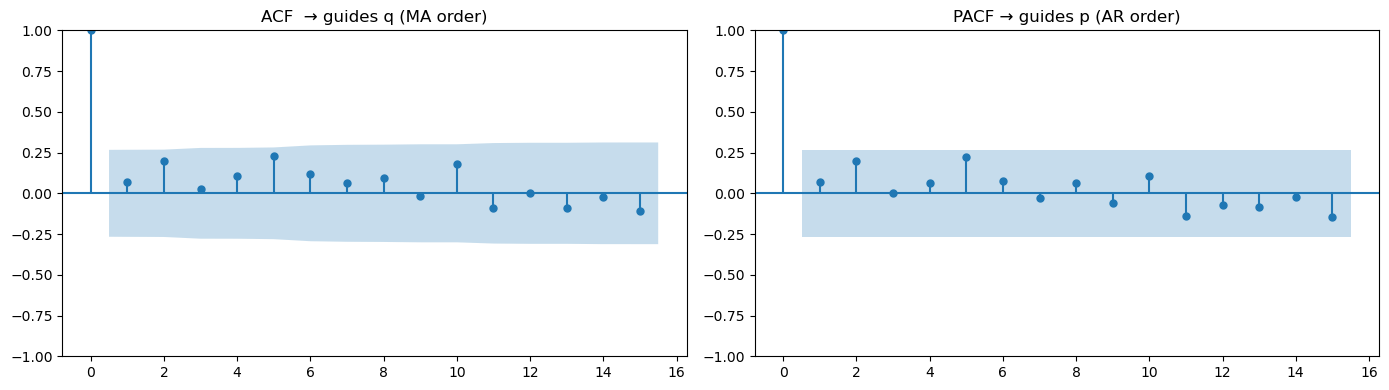

📌 Read the plots:
   • Count lags outside the shaded band in PACF → that gives p
   • Count lags outside the shaded band in ACF  → that gives q


In [5]:
series_for_acf = train.diff().dropna() if d == 1 else train

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(series_for_acf,  lags=15, ax=axes[0], title='ACF  → guides q (MA order)')
plot_pacf(series_for_acf, lags=15, ax=axes[1], title='PACF → guides p (AR order)')

plt.tight_layout()
plt.show()

print('📌 Read the plots:')
print('   • Count lags outside the shaded band in PACF → that gives p')
print('   • Count lags outside the shaded band in ACF  → that gives q')

## ✅ Step 6: Auto ARIMA Order Selection (AIC-based Grid Search)

> Tries all combinations of p ∈ [0..3], q ∈ [0..3] with the d value from the ADF test.  
> Selects the order with the **lowest AIC** (Akaike Information Criterion).

In [6]:
best_aic   = np.inf
best_order = None
results    = []

for p in range(4):          # AR order
    for q in range(4):      # MA order
        try:
            model = ARIMA(train, order=(p, d, q))
            fit   = model.fit()
            results.append({'p': p, 'd': d, 'q': q, 'AIC': round(fit.aic, 2)})
            if fit.aic < best_aic:
                best_aic   = fit.aic
                best_order = (p, d, q)
        except Exception:
            pass

results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
print('📊 Top 5 ARIMA orders by AIC:')
print(results_df.head())
print(f'\n🏆 Best order: ARIMA{best_order}  (AIC = {best_aic:.2f})')

📊 Top 5 ARIMA orders by AIC:
   p  d  q     AIC
0  0  0  0  881.10
1  2  0  0  882.47
2  1  0  1  882.49
3  0  0  2  882.66
4  1  0  0  882.83

🏆 Best order: ARIMA(0, 0, 0)  (AIC = 881.10)


## ✅ Step 7: Fit the Best ARIMA Model

In [7]:
arima_model = ARIMA(train, order=best_order)
arima_fit   = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 amount   No. Observations:                   54
Model:                          ARIMA   Log Likelihood                -438.552
Date:                Sun, 22 Feb 2026   AIC                            881.103
Time:                        20:41:13   BIC                            885.081
Sample:                    01-31-2020   HQIC                           882.637
                         - 06-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1858.8652    117.516     15.818      0.000    1628.538    2089.192
sigma2      6.642e+05   1.63e+05      4.065      0.000    3.44e+05    9.84e+05
Ljung-Box (L1) (Q):                   0.28   Jarque-

## ✅ Step 8: Forecast on Test Set

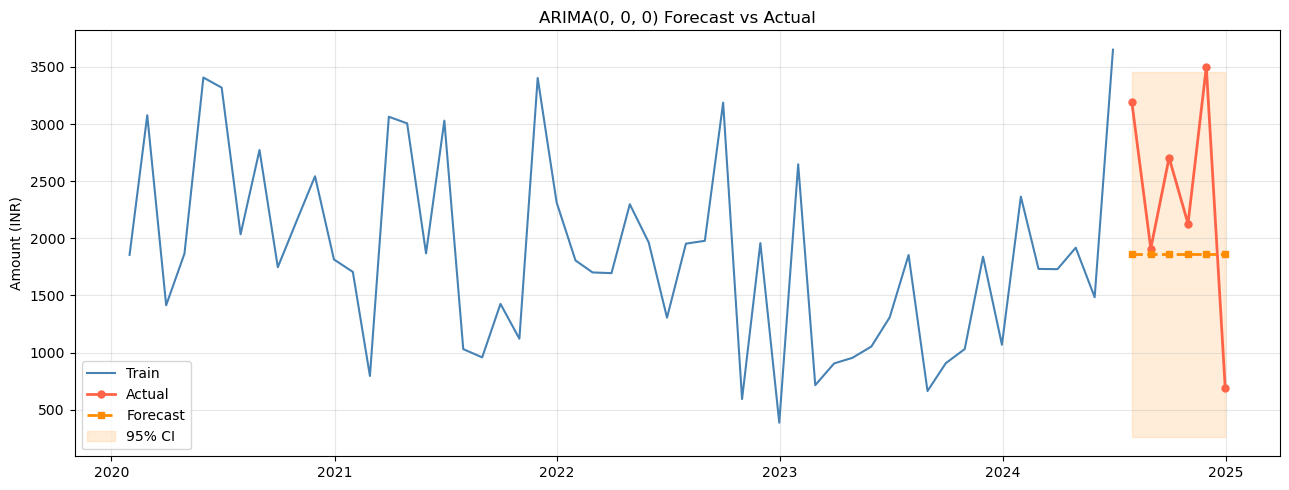

✅ Forecast plot saved.


In [8]:
# Forecast for the number of test months
forecast_result = arima_fit.get_forecast(steps=len(test))
forecast        = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int(alpha=0.05)   # 95% confidence interval

# Align index with test dates
forecast.index  = test.index
conf_int.index  = test.index

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index, train,    label='Train',    color='steelblue',  linewidth=1.5)
ax.plot(test.index,  test,     label='Actual',   color='tomato',     linewidth=2, marker='o', markersize=5)
ax.plot(test.index,  forecast, label='Forecast', color='darkorange', linewidth=2, linestyle='--', marker='s', markersize=5)
ax.fill_between(
    test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='darkorange', alpha=0.15, label='95% CI'
)
ax.set_title(f'ARIMA{best_order} Forecast vs Actual')
ax.set_ylabel('Amount (INR)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/processed/arima_forecast.png', dpi=120)
plt.show()
print('✅ Forecast plot saved.')

## ✅ Step 9: Evaluate — MAE, RMSE, MAPE

In [9]:
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test.values - forecast.values) / test.values)) * 100
rel_error = (rmse / test.mean()) * 100

print(f'📊 ARIMA{best_order} Evaluation on Test Set')
print(f'   MAE            : {mae:.2f} INR')
print(f'   RMSE           : {rmse:.2f} INR')
print(f'   MAPE           : {mape:.2f}%')
print(f'   Relative Error : {rel_error:.2f}%')

# Month-by-month comparison
comparison = pd.DataFrame({
    'Actual'  : test.values,
    'Forecast': forecast.values.round(2),
    'Error'   : (test.values - forecast.values).round(2),
    'APE (%)'  : (np.abs((test.values - forecast.values) / test.values) * 100).round(2)
}, index=test.index.strftime('%Y-%m'))

print(f'\n📅 Month-by-month breakdown:')
print(comparison.to_string())

📊 ARIMA(0, 0, 0) Evaluation on Test Set
   MAE            : 884.58 INR
   RMSE           : 1050.52 INR
   MAPE           : 50.77%
   Relative Error : 44.63%

📅 Month-by-month breakdown:
          Actual  Forecast    Error  APE (%)
date                                        
2024-07  3189.00   1858.87  1330.13    41.71
2024-08  1909.90   1858.87    51.03     2.67
2024-09  2706.00   1858.87   847.13    31.31
2024-10  2128.00   1858.87   269.13    12.65
2024-11  3500.02   1858.87  1641.15    46.89
2024-12   690.00   1858.87 -1168.87   169.40


## ✅ Step 10: Residual Analysis

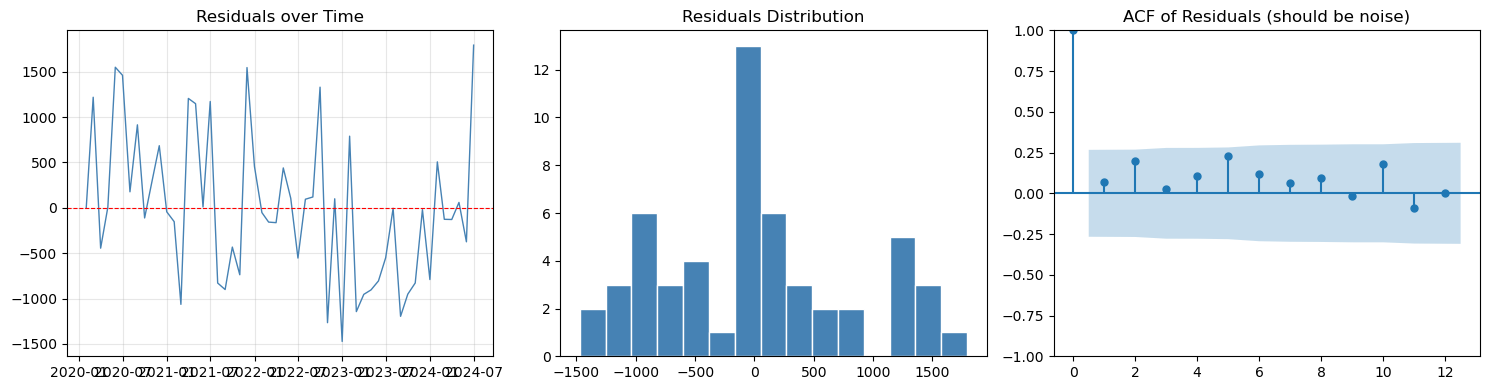


📌 Residual mean   : -0.00  (ideally ≈ 0)
📌 Residual std    : 821.99


In [10]:
# In-sample residuals (train residuals)
residuals = pd.Series(
    arima_fit.resid,
    index=train.index,
    name='residuals'
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals over time
axes[0].plot(residuals.index, residuals, color='steelblue', linewidth=1)
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('Residuals over Time')
axes[0].grid(True, alpha=0.3)

# Residuals histogram
axes[1].hist(residuals.dropna(), bins=15, color='steelblue', edgecolor='white')
axes[1].set_title('Residuals Distribution')

# ACF of residuals (should be white noise)
plot_acf(residuals.dropna(), lags=12, ax=axes[2], title='ACF of Residuals (should be noise)')

plt.tight_layout()
plt.show()

print(f'\n📌 Residual mean   : {residuals.mean():.2f}  (ideally ≈ 0)')
print(f'📌 Residual std    : {residuals.std():.2f}')

## ✅ Step 11: Save Residuals (for Hybrid Model)

In [11]:
# Save in-sample residuals (used by hybrid model as LSTM input)
residuals_df = residuals.reset_index()
residuals_df.columns = ['date', 'residuals']
residuals_df.to_csv('data/processed/arima_residuals.csv', index=False)

# Also save the forecast for later comparison
forecast_df = pd.DataFrame({
    'date'    : test.index,
    'actual'  : test.values,
    'forecast': forecast.values
})
forecast_df.to_csv('data/processed/arima_forecast.csv', index=False)

print('✅ Saved:')
print('   → data/processed/arima_residuals.csv')
print('   → data/processed/arima_forecast.csv')
print('   → data/processed/arima_forecast.png')

✅ Saved:
   → data/processed/arima_residuals.csv
   → data/processed/arima_forecast.csv
   → data/processed/arima_forecast.png
